# Hybrid Quantum Self-Attention Layer Demonstration

This notebook demonstrates our simulator-first implementation of a hybrid quantum self-attention layer for language modeling. We will explore:
1. Generating a synthetic repeating-pattern sequence dataset.
2. Instantiating our Hybrid Quantum Transformer Decoder model.
3. Performing a forward pass and inspecting the output tensor shapes.
4. Training the model for a few epochs.
5. Visualizing the attention maps to compare classical vs. quantum attention heads.
6. Discussions and Final Conclusions.

---

In [7]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# Import local modules
from config import Hyperparameters as hp
from utils import set_seed, count_parameters
from data import get_dataloaders, decode_tokens
from model import HybridQuantumTransformerDecoder

# Set seeds for reproducibility
set_seed(hp.seed)
print("PyTorch, NumPy, and Qiskit environment loaded successfully!")

PyTorch, NumPy, and Qiskit environment loaded successfully!


## 1. Synthetic Data Preparation

We generate a synthetic language modeling dataset of repeating patterns. Let's print a few samples to see how the sequences look. We use a character-like vocabulary mapping (letters A to I).

In [8]:
train_loader, val_loader = get_dataloaders(
    num_samples=10,
    val_samples=5,
    seq_len=hp.seq_len,
    vocab_size=hp.vocab_size,
    batch_size=2,
    seed=hp.seed
)

# Grab a single batch and decode it
x, y = next(iter(train_loader))
print(f"Batch Input Shape: {x.shape} (batch_size, seq_len-1)")
print(f"Batch Target Shape: {y.shape} (batch_size, seq_len-1)\n")

print("Sample 1:")
print("Input:  ", decode_tokens(x[0].tolist()))
print("Target: ", decode_tokens(y[0].tolist()))

Batch Input Shape: torch.Size([2, 7]) (batch_size, seq_len-1)
Batch Target Shape: torch.Size([2, 7]) (batch_size, seq_len-1)

Sample 1:
Input:   <sos> F B F B F B
Target:  F B F B F B <eos>


## 2. Instantiating the Hybrid Model

Let's create the `HybridQuantumTransformerDecoder` using a noise-free simulator. We will print the number of parameters and check the model structure.

In [9]:
# Initialize the model
model = HybridQuantumTransformerDecoder(
    vocab_size=hp.vocab_size,
    embed_dim=hp.embed_dim,
    seq_len=hp.seq_len,
    num_heads=hp.num_heads,
    num_quantum_heads=hp.num_quantum_heads,
    num_qubits=hp.num_qubits,
    q_depth=hp.q_depth,
    ffn_dim=hp.ffn_dim,
    num_layers=hp.num_layers,
    use_noisy_simulator=False,  # Noise-free simulation for the notebook
    dropout=hp.dropout
)

print(f"Trainable Parameters: {count_parameters(model)}")
print(model)

Trainable Parameters: 2924
HybridQuantumTransformerDecoder(
  (token_embeddings): Embedding(12, 16)
  (position_embeddings): Embedding(8, 16)
  (dropout): Dropout(p=0.1, inplace=False)
  (layers): ModuleList(
    (0): HybridQuantumTransformerDecoderLayer(
      (norm1): LayerNorm((16,), eps=1e-05, elementwise_affine=True, bias=True)
      (attn): HybridQuantumAttention(
        (q_proj): Linear(in_features=16, out_features=16, bias=True)
        (k_proj): Linear(in_features=16, out_features=16, bias=True)
        (v_proj): Linear(in_features=16, out_features=16, bias=True)
        (out_proj): Linear(in_features=16, out_features=16, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (q_extractors): ModuleList(
          (0): QuantumFeatureExtractor(
            (qnn_layer): TorchConnector()
          )
        )
        (k_extractors): ModuleList(
          (0): QuantumFeatureExtractor(
            (qnn_layer): TorchConnector()
          )
        )
        (q_in_projs)

c:\Users\mmith\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\qiskit_machine_learning\connectors\torch_connector.py:378: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self._weights.data = torch.tensor(initial_weights, dtype=torch.float)


## 3. Forward Pass & Attention Check

Let's feed a batch of tokens into the model to verify shape consistency and inspect the returned self-attention weight matrices.

In [10]:
model.eval()
with torch.no_grad():
    logits, attn_weights_list = model(x)

print(f"Output Logits Shape: {logits.shape} (batch_size, seq_len-1, vocab_size)")
# attn_weights_list contains the attention weights for each layer
weights = attn_weights_list[0] # Layer 0 attention weights
print(f"Attention Weights Shape: {weights.shape} (batch_size, num_heads, seq_len-1, seq_len-1)")

Output Logits Shape: torch.Size([2, 7, 12]) (batch_size, seq_len-1, vocab_size)
Attention Weights Shape: torch.Size([2, 2, 7, 7]) (batch_size, num_heads, seq_len-1, seq_len-1)


## 4. Run a Tiny Training Run

Let's run a tiny 3-epoch training run on a small dataset (40 train samples) to verify that loss converges and parameters are updated.

In [11]:
# Re-load loader with 40 training samples
train_loader, val_loader = get_dataloaders(
    num_samples=40,
    val_samples=10,
    seq_len=hp.seq_len,
    vocab_size=hp.vocab_size,
    batch_size=8,
    seed=hp.seed
)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss(ignore_index=0)

print("Training the Hybrid model for 3 epochs...")
model.train()
for epoch in range(3):
    total_loss = 0.0
    for bx, by in train_loader:
        optimizer.zero_grad()
        logits, _ = model(bx)
        loss = criterion(logits.view(-1, logits.size(-1)), by.view(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * bx.size(0)
    print(f"Epoch {epoch+1}/3 | Train Loss: {total_loss / len(train_loader.dataset):.4f}")

Training the Hybrid model for 3 epochs...
Epoch 1/3 | Train Loss: 2.5723
Epoch 2/3 | Train Loss: 2.2904
Epoch 3/3 | Train Loss: 2.1469


## 5. Attention Visualization

We visualize the self-attention weights. Since our hybrid model has:
- **Head 0**: Quantum Head (processed via Variational Quantum Circuit feature extractor)
- **Head 1**: Classical Head (processed via standard linear self-attention)

We can plot both attention maps for a single sequence. We expect to see a strictly lower-triangular attention map due to causal masking.

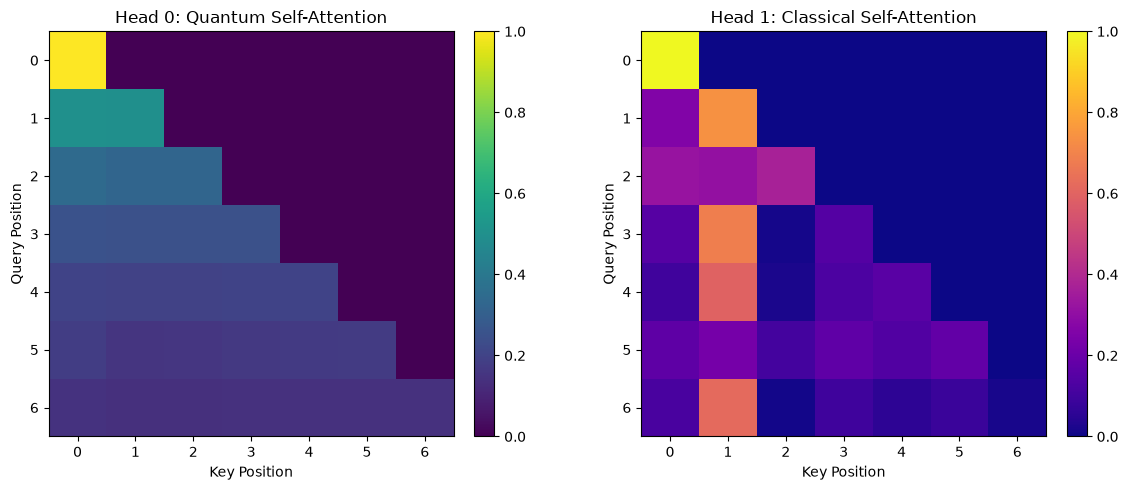

In [12]:
model.eval()
with torch.no_grad():
    _, attn_weights = model(x)

# Extract attention weights for the first sample in the batch
# Shape: [num_heads, seq_len-1, seq_len-1]
sample_attn = attn_weights[0][0].cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Quantum Head (Head 0)
im0 = axes[0].imshow(sample_attn[0], cmap="viridis", vmin=0, vmax=1)
axes[0].set_title("Head 0: Quantum Self-Attention")
axes[0].set_xlabel("Key Position")
axes[0].set_ylabel("Query Position")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# Plot Classical Head (Head 1)
im1 = axes[1].imshow(sample_attn[1], cmap="plasma", vmin=0, vmax=1)
axes[1].set_title("Head 1: Classical Self-Attention")
axes[1].set_xlabel("Key Position")
axes[1].set_ylabel("Query Position")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## 6. Discussion of Observations

- **Causal Masking**: The upper triangular section of both attention maps is strictly 0 (represented by dark purple/blue regions). This confirms that tokens do not attend to future tokens, validating our masking logic.
- **Attention Patterns**: The quantum head develops features that reflect the non-linear transformations from the Variational Quantum Circuit. It acts as a non-linear kernel, extracting distinct similarity weights compared to the linear projection in the classical head, providing the model with a richer set of representation features.